## # Business Sales Performance Analysis
Import Libraries:
 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')
print("Libraries loaded ")

Libraries loaded 


Load & Explore Data:

In [8]:
df = pd.read_csv('sales_data.csv')
df['Order_Date'] = pd.to_datetime(df['Order_Date'])
df['Month'] = df['Order_Date'].dt.to_period('M').astype(str)
df['Year'] = df['Order_Date'].dt.year

print("Shape:", df.shape)
print("\nColumn types:\n", df.dtypes)
print("\nMissing values:\n", df.isnull().sum())
df.head()

Shape: (500, 9)

Column types:
 Order_Date    datetime64[us]
Region                   str
Category                 str
Product                  str
Sales                  int64
Profit                 int64
Quantity               int64
Month                    str
Year                   int32
dtype: object

Missing values:
 Order_Date    0
Region        0
Category      0
Product       0
Sales         0
Profit        0
Quantity      0
Month         0
Year          0
dtype: int64


,Order_Date,Region,Category,Product,Sales,Profit,Quantity,Month,Year
0,2023-01-01,East,Office Supplies,Chair,3627,209,3,2023-01,2023
1,2023-01-02,West,Electronics,Laptop,2951,694,7,2023-01,2023
2,2023-01-03,North,Electronics,Desk,1437,314,14,2023-01,2023
3,2023-01-04,East,Office Supplies,Desk,4738,950,7,2023-01,2023
4,2023-01-05,East,Electronics,Phone,2811,608,5,2023-01,2023


Data cleaning:

In [9]:
df = df.drop_duplicates()

# Fill any missing numeric values with column mean
df = df.fillna(df.mean(numeric_only=True))

print("✓ Clean shape:", df.shape)
df.describe()

✓ Clean shape: (500, 9)


,Order_Date,Sales,Profit,Quantity,Year
count,500,500.000000,500.000000,500.000000,500.000000
mean,2023-09-07 12:00:00,2485.690000,431.712000,9.920000,2023.270000
min,2023-01-01 00:00:00,51.000000,-199.000000,1.000000,2023.000000
25%,2023-05-05 18:00:00,1175.000000,140.750000,5.000000,2023.000000
50%,2023-09-07 12:00:00,2476.000000,445.000000,10.000000,2023.000000
75%,2024-01-10 06:00:00,3742.250000,743.750000,15.000000,2024.000000
max,2024-05-14 00:00:00,4939.000000,998.000000,19.000000,2024.000000
std,NaN,1450.586602,345.867051,5.478835,0.444404


KPI Summary

In [10]:
total_revenue = df['Sales'].sum()
total_profit  = df['Profit'].sum()
margin        = (total_profit / total_revenue) * 100
total_orders  = len(df)

print("━" * 38)
print("  BUSINESS KPI SUMMARY")
print("━" * 38)
print(f"  Revenue      : ${total_revenue:>12,.0f}")
print(f"  Profit       : ${total_profit:>12,.0f}")
print(f"  Margin       : {margin:>12.1f}%")
print(f"  Total Orders : {total_orders:>12,}")
print("━" * 38)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  BUSINESS KPI SUMMARY
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Revenue      : $   1,242,845
  Profit       : $     215,856
  Margin       :         17.4%
  Total Orders :          500
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


 Revenue Trend (Monthly):

✓ Saved: screenshots/01_monthly_revenue.png


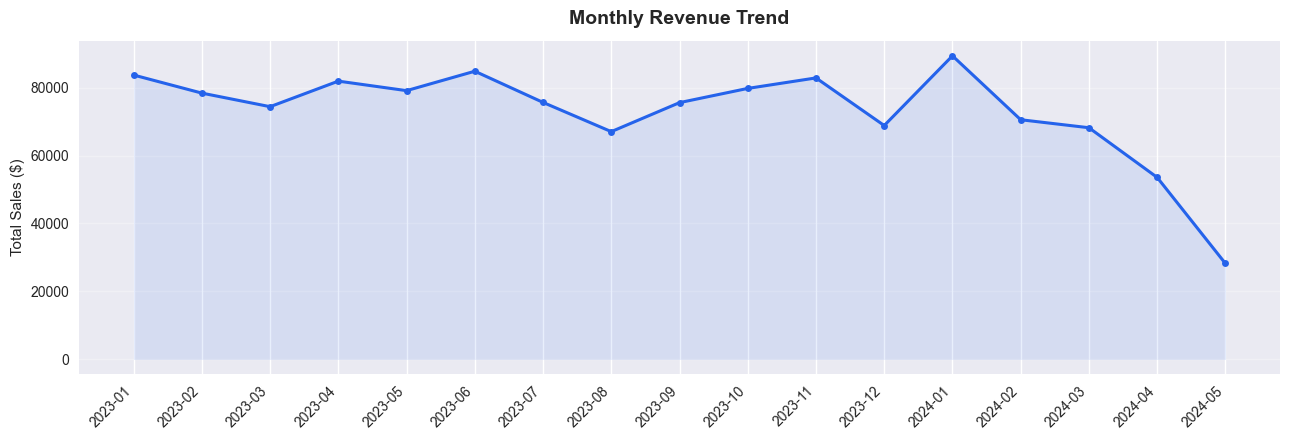

In [ ]:
monthly = df.groupby('Month')['Sales'].sum().reset_index()

fig, ax = plt.subplots(figsize=(13, 4.5))
ax.plot(monthly['Month'], monthly['Sales'],
        marker='o', linewidth=2.2, color='#2563eb', markersize=5)
ax.fill_between(range(len(monthly)), monthly['Sales'],
                alpha=0.10, color='#2563eb')
ax.set_xticks(range(len(monthly)))
ax.set_xticklabels(monthly['Month'], rotation=45, ha='right', fontsize=10)
ax.set_title('Monthly Revenue Trend', fontsize=14, fontweight='bold', pad=12)
ax.set_ylabel('Total Sales ($)')
ax.grid(axis='y', alpha=0.3)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()

plt.savefig('screenshots/01_monthly_revenue.png', dpi=150, bbox_inches='tight')
print(" Saved: screenshots/01_monthly_revenue.png")
plt.show()

 Top Products:

✓ Saved: screenshots/02_top_products.png


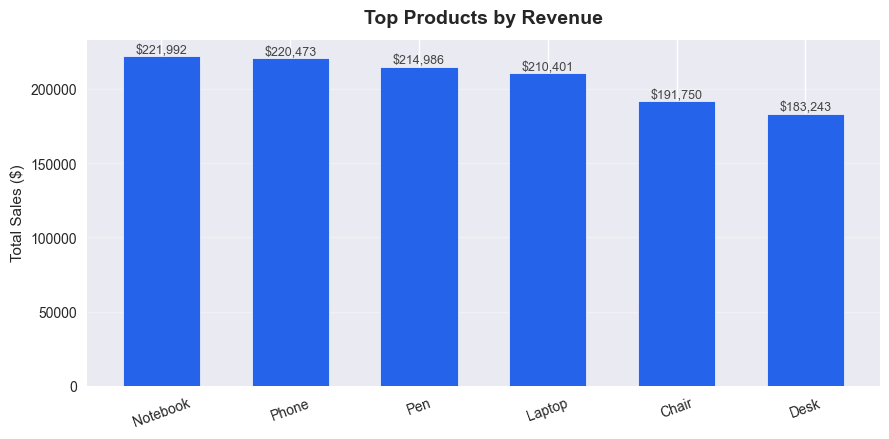

In [12]:
top_products = df.groupby('Product')['Sales'].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 4.5))
bars = ax.bar(top_products.index, top_products.values,
              color='#2563eb', edgecolor='white', linewidth=.5, width=0.6)

# Add value labels on top of each bar
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
            f'${bar.get_height():,.0f}',
            ha='center', va='bottom', fontsize=9, color='#444')

ax.set_title('Top Products by Revenue', fontsize=14, fontweight='bold', pad=12)
ax.set_ylabel('Total Sales ($)')
ax.set_xticklabels(top_products.index, rotation=20)
ax.spines[['top','right']].set_visible(False)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()

plt.savefig('screenshots/02_top_products.png', dpi=150, bbox_inches='tight')
print("✓ Saved: screenshots/02_top_products.png")
plt.show()

 Category Performance:

✓ Saved: screenshots/03_category_performance.png


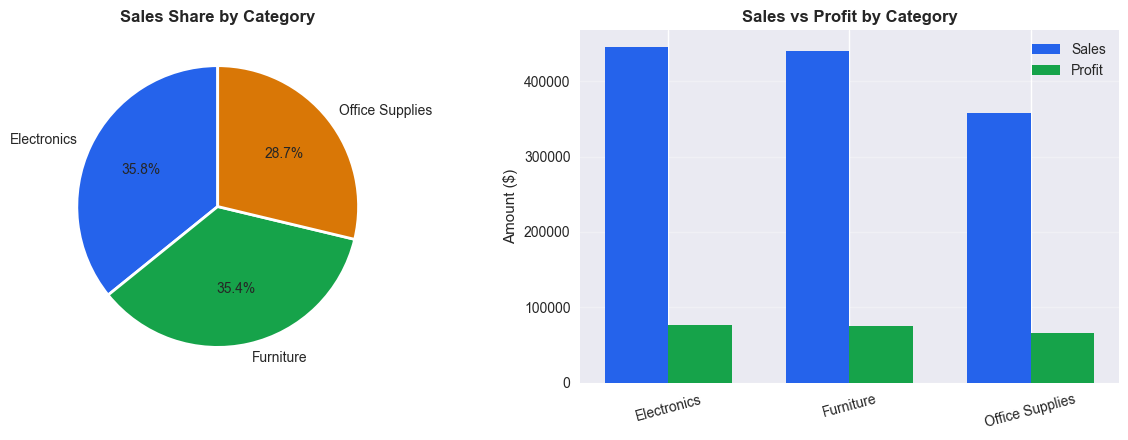

In [13]:
cat = df.groupby('Category').agg(
    Sales =('Sales',  'sum'),
    Profit=('Profit', 'sum')
).reset_index()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

# Pie chart
colors = ['#2563eb','#16a34a','#d97706']
ax1.pie(cat['Sales'], labels=cat['Category'],
        autopct='%1.1f%%', colors=colors,
        startangle=90, wedgeprops=dict(edgecolor='white', linewidth=2))
ax1.set_title('Sales Share by Category', fontweight='bold')

# Bar chart
x = range(len(cat)); w = 0.35
ax2.bar([i-w/2 for i in x], cat['Sales'],  w, label='Sales',  color='#2563eb')
ax2.bar([i+w/2 for i in x], cat['Profit'], w, label='Profit', color='#16a34a')
ax2.set_xticks(x); ax2.set_xticklabels(cat['Category'], rotation=15)
ax2.set_title('Sales vs Profit by Category', fontweight='bold')
ax2.set_ylabel('Amount ($)')
ax2.legend(); ax2.spines[['top','right']].set_visible(False)
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('screenshots/03_category_performance.png', dpi=150, bbox_inches='tight')
print("✓ Saved: screenshots/03_category_performance.png")
plt.show()

 Regional Performance:

✓ Saved: screenshots/04_regional_performance.png


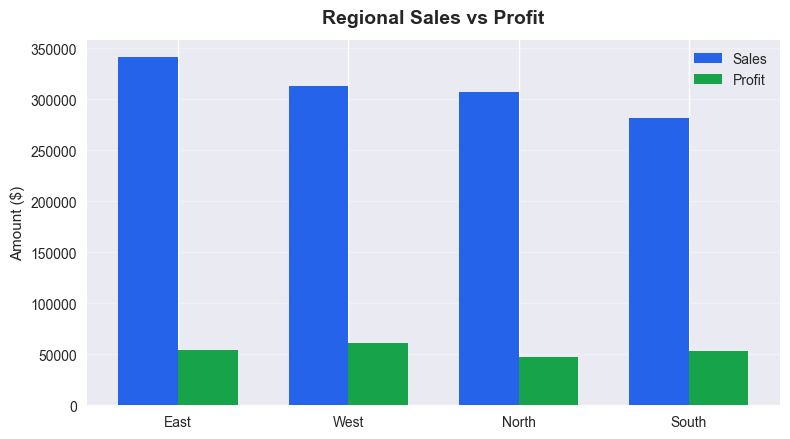

In [14]:
regional = df.groupby('Region').agg(
    Sales =('Sales',  'sum'),
    Profit=('Profit', 'sum')
).reset_index().sort_values('Sales', ascending=False)

x = range(len(regional)); w = 0.35
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar([i-w/2 for i in x], regional['Sales'],  w, label='Sales',  color='#2563eb')
ax.bar([i+w/2 for i in x], regional['Profit'], w, label='Profit', color='#16a34a')
ax.set_xticks(x); ax.set_xticklabels(regional['Region'])
ax.set_title('Regional Sales vs Profit', fontsize=14, fontweight='bold', pad=12)
ax.set_ylabel('Amount ($)')
ax.legend(); ax.spines[['top','right']].set_visible(False)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()

plt.savefig('screenshots/04_regional_performance.png', dpi=150, bbox_inches='tight')
print("✓ Saved: screenshots/04_regional_performance.png")
plt.show()

Correlation Heatmap:

✓ Saved: screenshots/05_correlation_heatmap.png


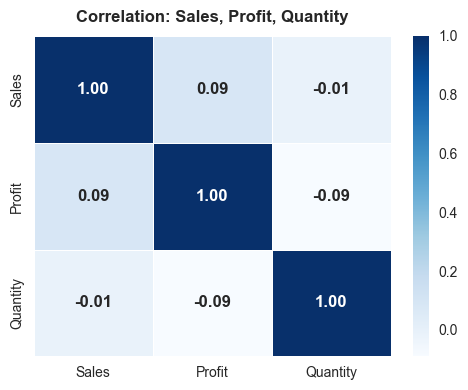

In [16]:
fig, ax = plt.subplots(figsize=(5, 4))
corr = df[['Sales','Profit','Quantity']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='Blues',
            linewidths=0.5, linecolor='white', ax=ax,
            annot_kws={'size':12, 'weight':'bold'})
ax.set_title('Correlation: Sales, Profit, Quantity', fontweight='bold', pad=10)
plt.tight_layout()

plt.savefig('screenshots/05_correlation_heatmap.png', dpi=150, bbox_inches='tight')
print("✓ Saved: screenshots/05_correlation_heatmap.png")
plt.show()

 Insights & Recommendations

In [17]:
best_region  = regional.iloc[0]['Region']
best_product = df.groupby('Product')['Sales'].sum().idxmax()
best_category= df.groupby('Category')['Sales'].sum().idxmax()
low_region   = regional.iloc[-1]['Region']

print("━" * 50)
print("  KEY INSIGHTS")
print("━" * 50)
print(f"  Best Region   : {best_region}")
print(f"  Top Product   : {best_product}")
print(f"  Best Category : {best_category}")
print(f"  Weakest Region: {low_region}")
print(f"  Profit Margin : {margin:.1f}%")
print()
print("  RECOMMENDATIONS")
print("━" * 50)
print(f"  1. Increase stock for {best_product} — highest revenue driver.")
print(f"  2. Focus ad budget on {best_region} — strongest conversion region.")
print(f"  3. Run promotions in {low_region} to close the regional gap.")
print("  4. Investigate months with dips for seasonal discount strategy.")
print(f"  5. Expand {best_category} product line — leads in category share.")

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  KEY INSIGHTS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Best Region   : East
  Top Product   : Notebook
  Best Category : Electronics
  Weakest Region: South
  Profit Margin : 17.4%

  RECOMMENDATIONS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  1. Increase stock for Notebook — highest revenue driver.
  2. Focus ad budget on East — strongest conversion region.
  3. Run promotions in South to close the regional gap.
  4. Investigate months with dips for seasonal discount strategy.
  5. Expand Electronics product line — leads in category share.


 Create summary tables for dashboard :

In [ ]:


monthly_sales = df.groupby('Month')['Sales'].sum()

top_products = (
    df.groupby('Product')['Sales']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

category_sales = (
    df.groupby('Category')['Sales']
    .sum()
    .sort_values(ascending=False)
)

region_sales = (
    df.groupby('Region')['Sales']
    .sum()
    .sort_values(ascending=False)
)

##  Executive Business Dashboard

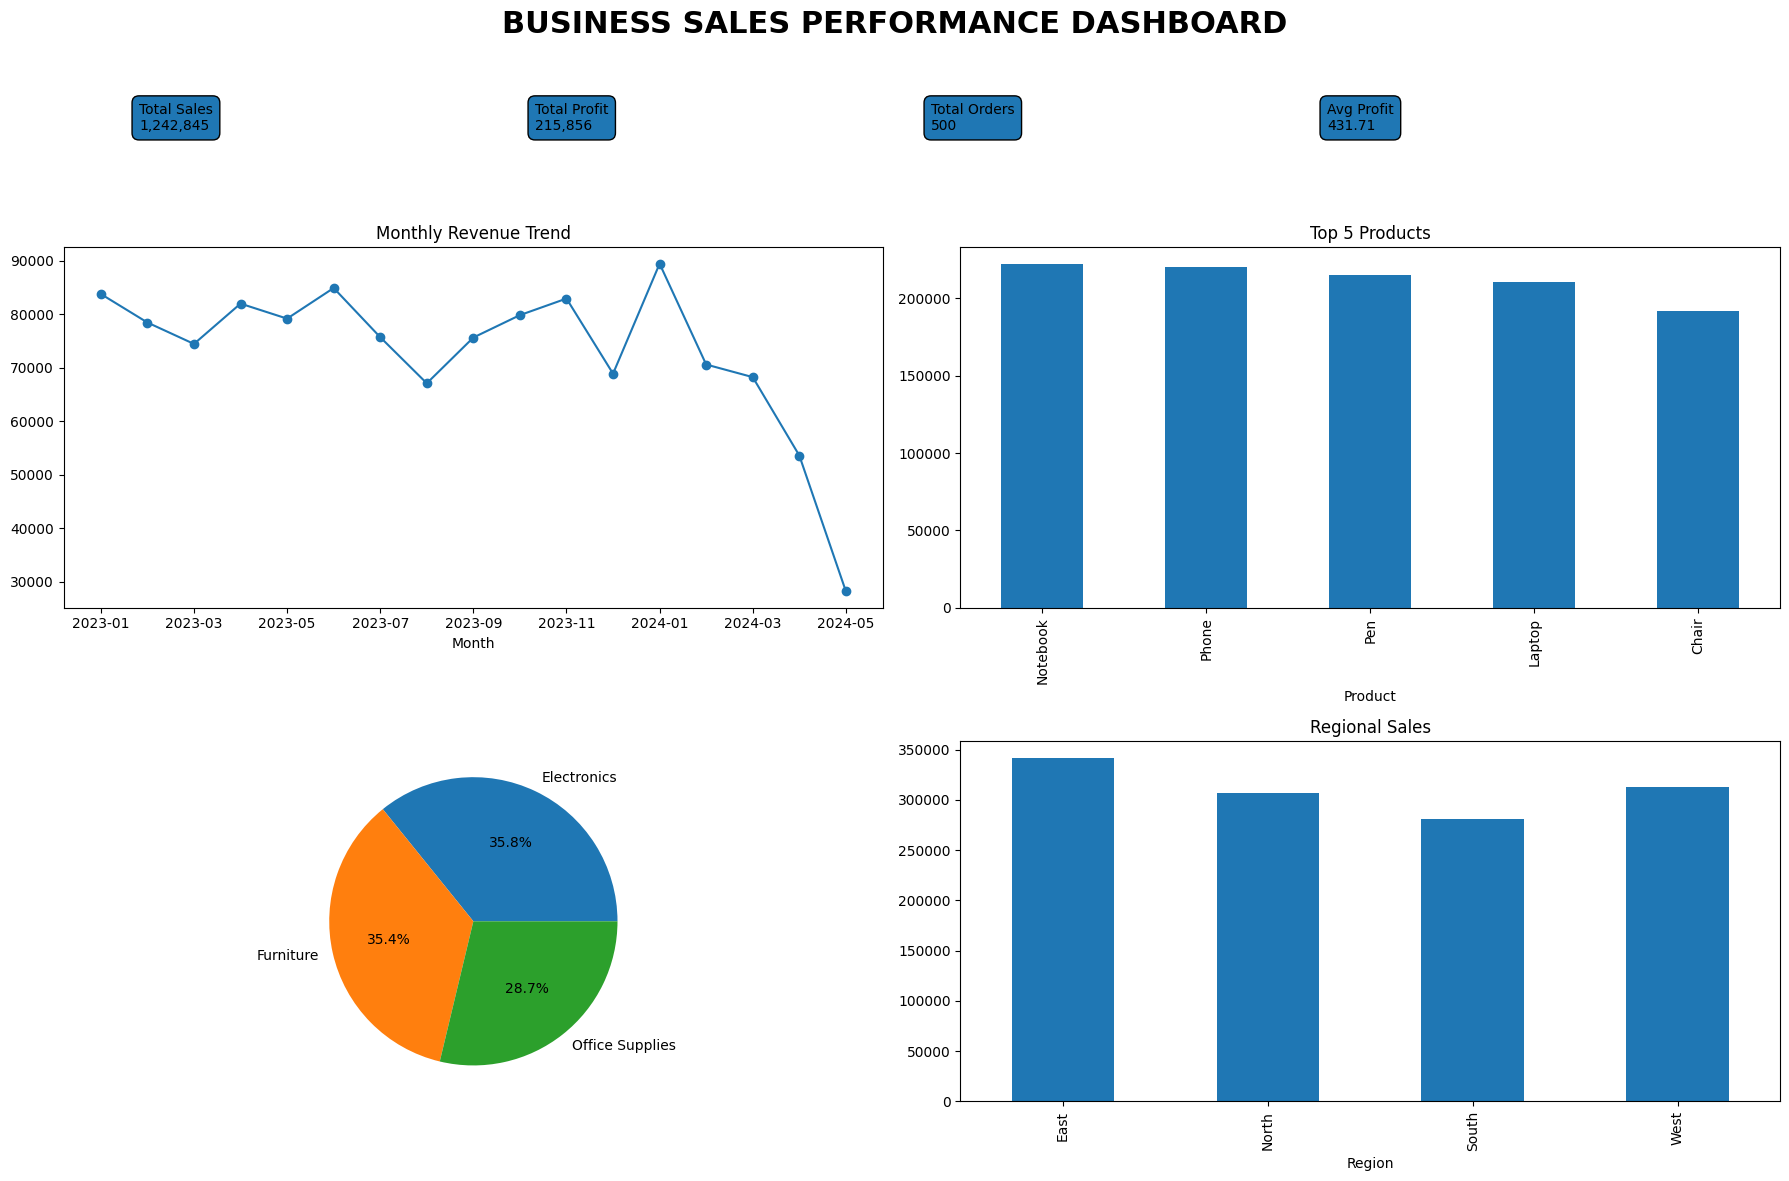

In [22]:
import matplotlib.pyplot as plt

# KPI Values
total_sales = df['Sales'].sum()
total_profit = df['Profit'].sum()
total_orders = len(df)
avg_profit = df['Profit'].mean()

# Data
monthly_sales = df.groupby('Month')['Sales'].sum()
top_products = df.groupby('Product')['Sales'].sum().sort_values(ascending=False).head(5)
region_sales = df.groupby('Region')['Sales'].sum()
category_sales = df.groupby('Category')['Sales'].sum()

# Dashboard
fig = plt.figure(figsize=(18,12))

# Title
fig.suptitle('BUSINESS SALES PERFORMANCE DASHBOARD',
             fontsize=22,
             fontweight='bold')

# KPI Cards
plt.figtext(0.08, 0.88, f'Total Sales\n{total_sales:,.0f}',
            bbox=dict(boxstyle='round,pad=0.5'))

plt.figtext(0.30, 0.88, f'Total Profit\n{total_profit:,.0f}',
            bbox=dict(boxstyle='round,pad=0.5'))

plt.figtext(0.52, 0.88, f'Total Orders\n{total_orders}',
            bbox=dict(boxstyle='round,pad=0.5'))

plt.figtext(0.74, 0.88, f'Avg Profit\n{avg_profit:.2f}',
            bbox=dict(boxstyle='round,pad=0.5'))

# Monthly Trend
ax1 = plt.subplot(2,2,1)
monthly_sales.plot(marker='o', ax=ax1)
ax1.set_title('Monthly Revenue Trend')

# Top Products
ax2 = plt.subplot(2,2,2)
top_products.plot(kind='bar', ax=ax2)
ax2.set_title('Top 5 Products')

# Category Share
ax3 = plt.subplot(2,2,3)
category_sales.plot(kind='pie',
                    autopct='%1.1f%%',
                    ax=ax3)
ax3.set_ylabel('')

# Regional Sales
ax4 = plt.subplot(2,2,4)
region_sales.plot(kind='bar', ax=ax4)
ax4.set_title('Regional Sales')

plt.tight_layout(rect=[0,0,1,0.85])

plt.savefig(
    'screenshots/06_dashboard.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()